# Importing Data to test yfinance viability for this project.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data") # Pulls data from the data folder in the parent directory
DATA_DIR.mkdir(exist_ok=True) #  Checks weather the folder exists, if not it creates it

print ("Imports OK - Pandas", pd.__version__) #if the imports are successful, it will print the version of pandas

Imports OK - Pandas 3.0.3


## Getting Wikipedia datas to create a roster list for the companies in S&P 500. 

In [2]:
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()          # stops loudly if the download failed

tables = pd.read_html(StringIO(response.text))
sp500 = tables[0]
print(sp500.shape)
sp500.head()


(503, 8)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Extracting all the symbols to a list. 
### Issue: Wikipedia stores Symbol names with "." symbol if there is a space. yFinance stores it with a "-". 
### Fix: Use .replace(".", "-") to switch all the "." symbols for "-" so that the symbols match accross both platforms while calling the tickers.

In [3]:
tickers = sp500["Symbol"].str.replace(".", "-", regex=False).tolist() # Replace periods with hyphens in stock symbols to match Yahoo Finance format and convert to list
print(f"{len(tickers)} tickers")
print([t for t in tickers if "-" in t])
print(tickers[:15])


503 tickers
['BRK-B', 'BF-B']
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE']


## prove the pipeline on a tiny slice before you scale
## Picking first 10 tickers from wikipedia roster and calling on yFinance API to give data on those 10 tickers

In [4]:
test_tickers = tickers[:10]

data = yf.download(
    test_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=True,
)

print(data.shape)
data.head()




[*********************100%***********************]  10 of 10 completed

(2516, 50)


Price           Close                                                        \
Ticker              A       ABBV        ABT        ACN       ADBE       AES   
Date                                                                          
2015-01-02  36.899395  41.119240  35.754196  72.753403  72.339996  8.907227   
2015-01-05  36.207985  40.345398  35.762173  71.525032  71.980003  8.653666   
2015-01-06  35.643940  40.145706  35.356052  71.009087  70.529999  8.458616   
2015-01-07  36.117004  41.768253  35.642719  72.499565  71.110001  8.471619   
2015-01-08  37.199604  42.205093  36.375324  73.605118  72.919998  8.601651   

Price                                              ...   Volume           \
Ticker            AFL   AMD        AOS        MMM  ...        A     ABBV   
Date                                               ...                     
2015-01-02  23.306971  2.67  23.225430  95.186951  ...  1529200  5086100   
2015-01-05  22.696438  2.66  22.819057  93.040215  ...  2041800  8007400   
2015-01-06  22.494204  2.63  22.632458  92.048111  ...  2080600  5483700   
2015-01-07  22.635386  2.58  22.798319  92.715324  ...  3359700  8283300   
2015-01-08  22.856710  2.61  23.391296  94.937454  ...  2116300  7949000   

Price                                                                       \
Ticker          ABT      ACN     ADBE      AES      AFL       AMD      AOS   
Date                                                                         
2015-01-02  3216600  2021300  2349200  5228700  2846000         0  1540200   
2015-01-05  5735900  3000000  2403300  5411400  4757000   8878200  1073000   
2015-01-06  6584300  2867000  2895400  7171200  5819000  13912500  1124600   
2015-01-07  4609500  2865500  2378300  4932000  3653400  12377600   977600   
2015-01-08  4883000  2802900  2624200  6674400  4587600  11136600   965200   

Price                
Ticker          MMM  
Date                 
2015-01-02  2531214  
2015-01-05  4416708  
2015-01-06  4224272  
2015-01-07  3685235  
2015-01-08  3758908  

[5 rows x 50 columns]

## Next to check whether there are any missing values in the tickers above. 

In [5]:
close = data["Close"]
print(close.isna().sum())


Ticker
A       0
ABBV    0
ABT     0
ACN     0
ADBE    0
AES     0
AFL     0
AMD     0
AOS     0
MMM     0
dtype: int64


## Downloading data from yFinance and saving it to the disk for consistent data throughout this research
### Also helps me reproduce the results! 

In [6]:
data = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=True,
)

print("Shape:", data.shape)
out_path = DATA_DIR / "sp500_ohlcv_2015_2025.parquet"
data.to_parquet(out_path)
print("Saved to:", out_path)


[****                   9%                       ]  43 of 503 completed$FDXF: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[**********************69%********               ]  346 of 503 completed$HONA: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[**********************84%***************        ]  423 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[**********************90%******************     ]  453 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[*********************100%***********************]  503 of 503 c

Shape: (2516, 2519)
Saved to: ..\data\sp500_ohlcv_2015_2025.parquet


## ['SNDK', 'FDXF', 'Q', 'HONA'] are either delisted, symbol changed or data's does not exist.

In [7]:
data["Close"].isna().sum() 

Ticker
A          0
AAPL       0
ABBV       0
ABNB    1496
ABT        0
        ... 
XYZ      223
YUM        0
ZBH        0
ZBRA       0
ZTS        0
Length: 503, dtype: int64

# Checking for XYZ decrepency. 

In [8]:
xyz = data["Close"]["XYZ"]
print("First valid date:", xyz.first_valid_index())
print("Last valid date:", xyz.last_valid_index())
print(xyz.dropna().head())


First valid date: 2015-11-19 00:00:00
Last valid date: 2024-12-31 00:00:00
Date
2015-11-19    13.07
2015-11-20    12.85
2015-11-23    12.12
2015-11-24    12.02
2015-11-25    11.90
Name: XYZ, dtype: float64


## SO even though XYZ was only added in 2025 in S&P 500, it still includes data from 2015 to 2024. 

## Checking whether other data sets have missing closing prices too. 
## Except for SNDK, HONA, FDXF and Q, they are all late entrants which explains their missing front value gaps. 

In [9]:
na = data["Close"].isna().sum()
print(na[na > 0].sort_values(ascending=False).head(15))


Ticker
SNDK    2516
HONA    2516
FDXF    2516
Q       2516
GEV     2323
SOLV    2322
VLTO    2203
KVUE    2098
GEHC    2003
CEG     1774
HOOD    1654
APP     1581
COIN    1580
EXE     1537
ABNB    1496
dtype: int64


## Make the drop explicit and re-save, so the on-disk dataset is the clean one every downstream notebook loads

In [10]:
fully_missing = data["Close"].isna().sum()
dead = fully_missing[fully_missing == len(data)].index.tolist()
print("Dropping (no data):", dead)

clean = data.drop(columns=dead, level=1)
print("Shape after drop:", clean.shape)

clean.to_parquet(DATA_DIR / "sp500_ohlcv_2015_2025_clean.parquet")
print("Saved clean dataset.")


Dropping (no data): ['FDXF', 'HONA', 'Q', 'SNDK']
Shape after drop: (2516, 2495)
Saved clean dataset.


## You wanted log returns: ln(today / yesterday).

In [11]:
close = clean["Close"]
log_returns = np.log(close / close.shift(1))


In [12]:
print(log_returns.shape)
print(log_returns["AAPL"].describe())

(2516, 499)
count    2515.000000
mean        0.000927
std         0.017931
min        -0.137708
25%        -0.007353
50%         0.001000
75%         0.010091
max         0.113158
Name: AAPL, dtype: float64


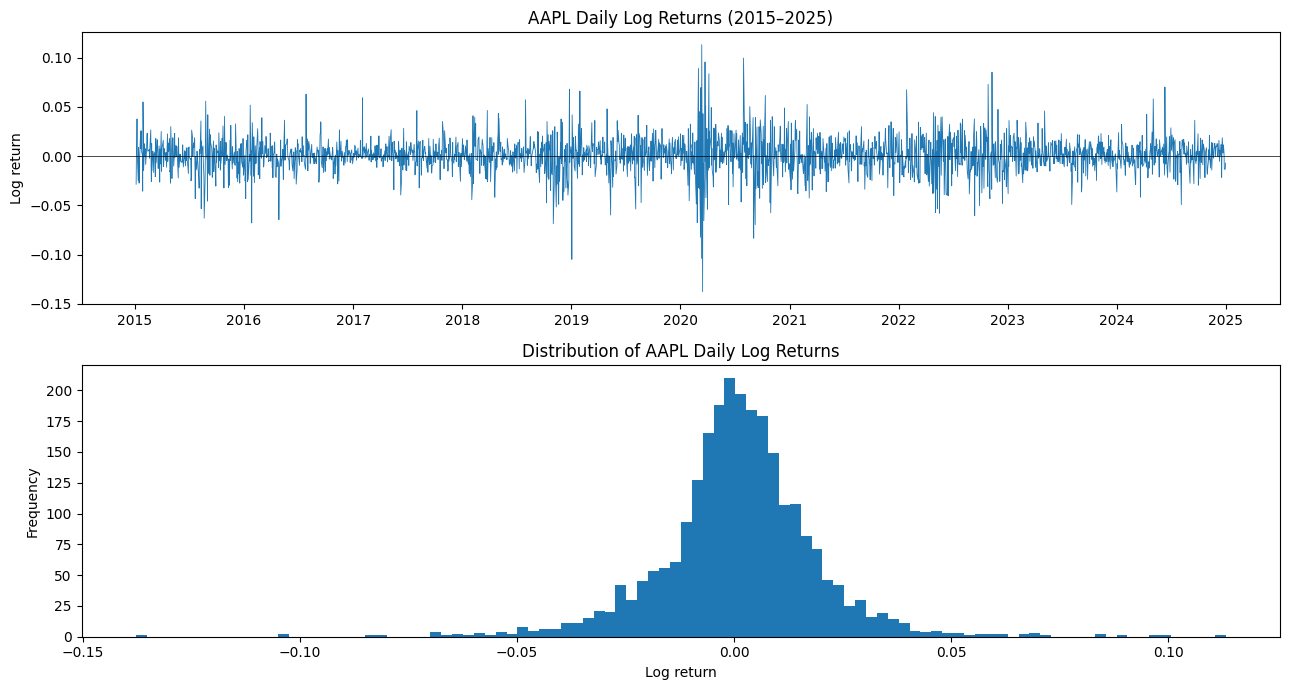

In [13]:
aapl_ret = log_returns["AAPL"].dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

# Panel 1: returns over time
ax1.plot(aapl_ret.index, aapl_ret.values, linewidth=0.6)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_title("AAPL Daily Log Returns (2015–2025)")
ax1.set_ylabel("Log return")

# Panel 2: distribution of returns
ax2.hist(aapl_ret.values, bins=100)
ax2.set_title("Distribution of AAPL Daily Log Returns")
ax2.set_xlabel("Log return")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Using Trailing Mean and SD to calcular normal distrubution (z-distribution)

In [14]:
window = 20
rolling_mean = log_returns.rolling(window=window).mean()
rolling_std = log_returns.rolling(window=window).std()

zscore_returns = (log_returns - rolling_mean) / rolling_std

print(zscore_returns.shape)
print(zscore_returns["AAPL"].describe())


(2516, 499)
count    2496.000000
mean       -0.021845
std         0.981877
min        -3.390475
25%        -0.622980
50%        -0.040593
75%         0.609399
max         3.931073
Name: AAPL, dtype: float64


## Rolling Volatility for 5 days window, 20 days window, and 60 days window. 

### This lets models see volatility at different time scales simultaneously 

In [15]:
vol_5  = log_returns.rolling(window=5).std()
vol_20 = log_returns.rolling(window=20).std()
vol_60 = log_returns.rolling(window=60).std()

print(vol_20["AAPL"].describe())


count    2496.000000
mean        0.016251
std         0.007657
min         0.004805
25%         0.011231
50%         0.014658
75%         0.019145
max         0.068108
Name: AAPL, dtype: float64


## Inserting Volume input to check the stable days and unstable ones. 

In [16]:
volume = clean["Volume"] 
log_volume = np.log1p(volume)


## Using rolling volumes to not generalize it in a span on a decade, rather than a 20 days rolling window.

In [17]:
window = 20
rolling_mean = log_volume.rolling(window=window).mean()
rolling_std  = log_volume.rolling(window=window).std()

zscore_volume = (log_volume - rolling_mean) / rolling_std

print(zscore_volume.shape)
print(zscore_volume["AAPL"].describe())

(2516, 499)
count    2497.000000
mean       -0.042728
std         1.066521
min        -3.067656
25%        -0.798303
50%        -0.207705
75%         0.599434
max         3.788374
Name: AAPL, dtype: float64


## To check whether high volume days match the high price movement days

In [18]:
ret_z = zscore_returns["AAPL"]
vol_z = zscore_volume["AAPL"]
print("Correlation between return-z and volume-z:", ret_z.corr(vol_z))


Correlation between return-z and volume-z: -0.04419240349571436


## Since it's a low correlation between the price and volume, it is wise to keep both as an indicator for anomalous days.

## Now to stack up the z-score distribution table for log_returns, log_volatility, log_volume, and volatility so that it sits well in a single table for my module to learn from. 

In [19]:
features = pd.concat(
    {
        "ret_zscore": zscore_returns.stack(),
        "vol_5":      vol_5.stack(),
        "vol_20":     vol_20.stack(),
        "vol_60":     vol_60.stack(),
        "vol_zscore": zscore_volume.stack(),
    },
    axis=1,
)

print(features.shape)
features.head(10)

(1255484, 5)


ret_zscore  vol_5  vol_20  vol_60  vol_zscore
Date       Ticker                                               
2015-01-02 A              NaN    NaN     NaN     NaN         NaN
           AAPL           NaN    NaN     NaN     NaN         NaN
           ABBV           NaN    NaN     NaN     NaN         NaN
           ABNB           NaN    NaN     NaN     NaN         NaN
           ABT            NaN    NaN     NaN     NaN         NaN
           ACGL           NaN    NaN     NaN     NaN         NaN
           ACN            NaN    NaN     NaN     NaN         NaN
           ADBE           NaN    NaN     NaN     NaN         NaN
           ADI            NaN    NaN     NaN     NaN         NaN
           ADM            NaN    NaN     NaN     NaN         NaN

## Due to the rolling window period most of the early dates would come out to be NaN datas.

### Cleaning up the data next so that we have all the features present so that the model trains properly.

### longest window is 60 days, so every stock effectively "starts" 60 trading days after its first data point — that's when it first has a complete feature vector

In [20]:
features_clean = features.dropna()
print("Before:", features.shape)
print("After: ", features_clean.shape)

Before: (1255484, 5)
After:  (1184191, 5)


## This is now a clean data set a model can work with.

### It consists of all the data required for a model to train on.

## Now saving it in the disk to use it later

In [21]:
features_clean.to_parquet(DATA_DIR / "features_clean.parquet")

print("Saved feature matrix:", features_clean.shape)

Saved feature matrix: (1184191, 5)
